In [6]:
# Import libraries
import rasterio as rio
import numpy as np
import matplotlib.pyplot as plt

In [7]:
# Open and read envisat data
path_img = 'envisat_wsm_2005_09_12_hh_pot_cal_cg_gk5wgs84_nn_sub.tif'
with rio.open(path_img) as src:
    img = src.read()

In [8]:
# Check envisat metadata
src.meta

{'driver': 'GTiff',
 'dtype': 'float32',
 'nodata': None,
 'width': 3240,
 'height': 3905,
 'count': 1,
 'crs': CRS.from_wkt('PROJCS["unnamed",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",-90],PARAMETER["central_meridian",-60],PARAMETER["scale_factor",1],PARAMETER["false_easting",5500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]'),
 'transform': Affine(75.0, 0.0, 5422474.571066083,
        0.0, -75.0, 6454511.472026689)}

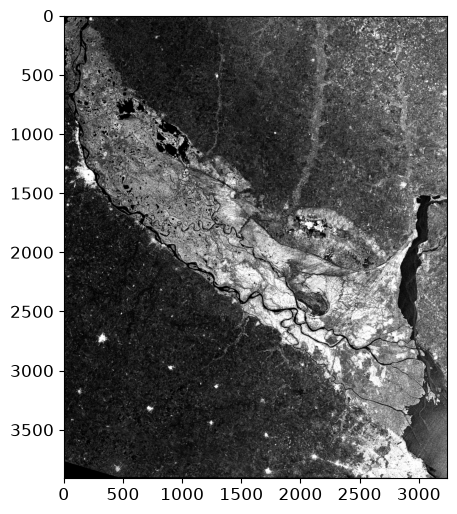

In [ ]:
# Raw image visualization
fig, ax = plt.subplots(figsize=(8, 6))
ax.imshow(img[0], cmap='gray', vmin = np.nanpercentile(img, 5), vmax=np.nanpercentile(img, 95))

In [ ]:
# Define amplitud (amp) and decibels (dec) functions
def amp(x):
    return np.sqrt(x)

def dec(x):
    return 10*np.log10(x)

<>:10: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:19: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:29: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:10: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:19: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:29: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
/tmp/ipykernel_24501/3131215206.py:10: SyntaxWarning: "\s" is an invalid esc

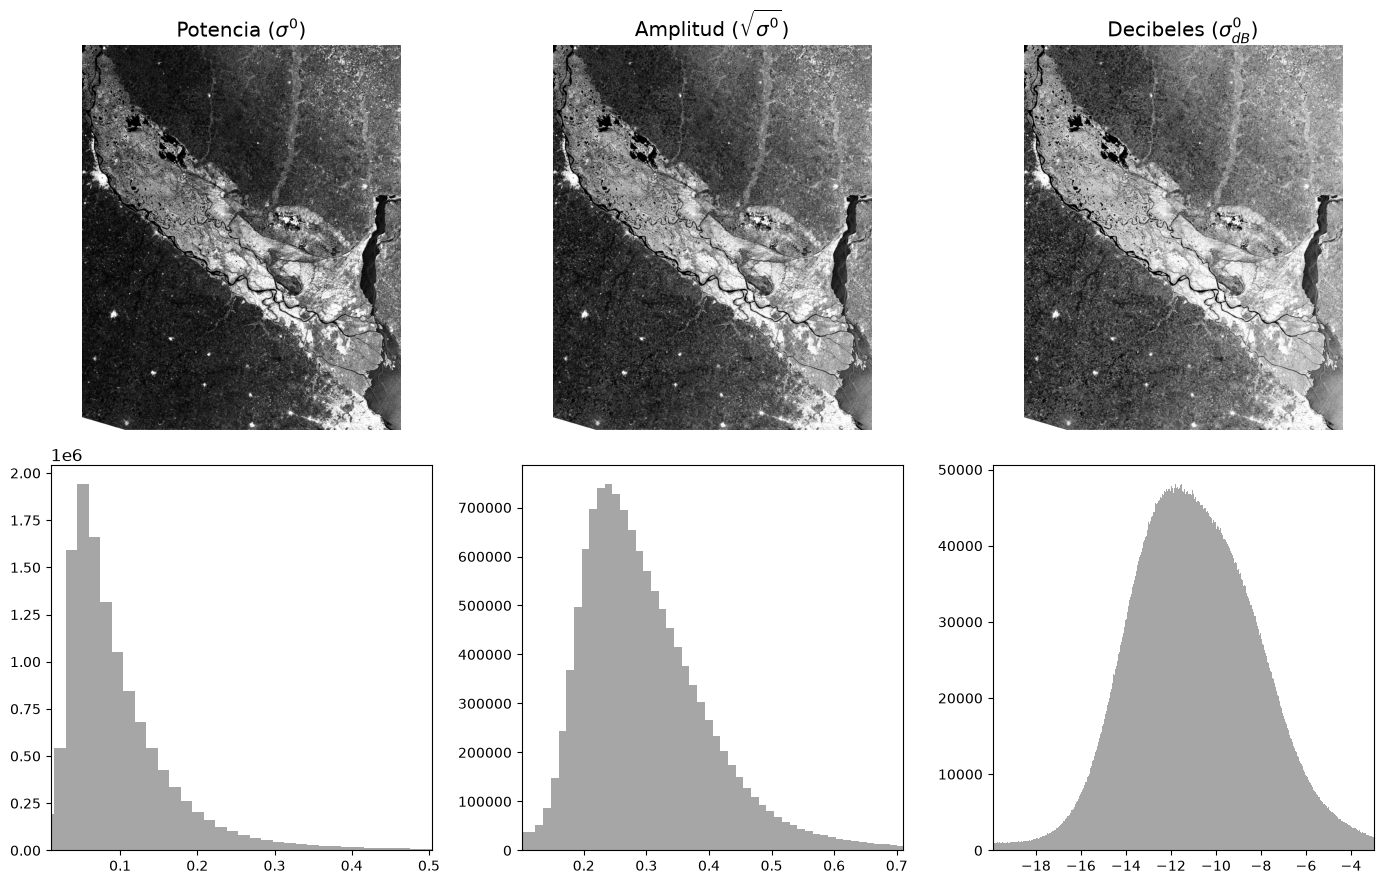

In [76]:
# Mask background values (0)
img[0][img[0] == 0] = np.nan

# Plot data and histograms
fig, ax = plt.subplots(2, 3, figsize=(14, 9), tight_layout=True)

# Potencia
ax[0, 0].imshow(img[0], cmap='gray', vmin = np.nanpercentile(img, 5), vmax=np.nanpercentile(img, 95))
ax[0, 0].set_axis_off()
ax[0, 0].set_title('Potencia ($\sigma^0$)')

ax[1, 0].hist(img[0].ravel(), bins=int(np.unique(img[0]).size/1000), color='gray', alpha=0.7)
ax[1, 0].set_xlim(left=np.nanpercentile(img[0], 1), right=np.nanpercentile(img[0], 99)) # Sets max X-axis value to p-991, 
ax[1, 0].tick_params(labelsize=10)

# Amplitud 
ax[0, 1].imshow(amp(img[0]), cmap='gray', vmin = np.nanpercentile(amp(img[0]), 5), vmax=np.nanpercentile(amp(img[0]), 95))
ax[0, 1].set_axis_off()
ax[0, 1].set_title('Amplitud ($\sqrt{\sigma^0}$)')

ax[1, 1].hist(amp(img[0]).ravel(), bins = 1000, color='gray', alpha=0.7)
ax[1, 1].set_xlim(left=np.nanpercentile(amp(img[0]), 1), right=np.nanpercentile(amp(img[0]), 99)) # Sets max X-axis value to p-99
ax[1, 1].tick_params(labelsize=10)


# Potencia
ax[0, 2].imshow(dec(img[0]), cmap='gray', vmin = np.nanpercentile(dec(img[0]), 5), vmax=np.nanpercentile(dec(img[0]), 95))
ax[0, 2].set_axis_off()
ax[0, 2].set_title('Decibeles ($\sigma^0_{dB}$)')

ax[1, 2].hist(dec(img[0]).ravel(), bins=5000, color='gray', alpha=0.7)
ax[1, 2].set_xlim(left=np.nanpercentile(dec(img[0]), 1), right=np.nanpercentile(dec(img[0]), 99)) # Sets max X-axis value to p-99
ax[1, 2].tick_params(labelsize=10)

In [81]:
# Define data stats

def resp_stats(x):
    
    return {'mean': np.nanmean(x),
            'std': np.nanstd(x),
            'max': np.nanmax(x), 
            'min': np.nanmin(x),
            '25-q': np.nanquantile(x, 0.25),
            '50-q': np.nanquantile(x, 0.50),
            '75-q': np.nanquantile(x, 0.75)}

In [ ]:
# Statistics according to the response representation
print('Potencia Stats', resp_stats(img[0]))
print('Amplitud Stats', resp_stats(amp(img[0])))
print('Decibeles Stats', resp_stats(dec(img[0])))

Potencia Stats {'mean': np.float32(0.10866268), 'std': np.float32(0.22867459), 'max': np.float32(151.17624), 'min': np.float32(2.1817947e-12), '25-q': np.float32(0.050866682), '50-q': np.float32(0.078246735), '75-q': np.float32(0.12537867)}
Amplitud Stats {'mean': np.float32(0.302962), 'std': np.float32(0.12991035), 'max': np.float32(12.295375), 'min': np.float32(1.4770899e-06), '25-q': np.float32(0.22553644), '50-q': np.float32(0.27972618), '75-q': np.float32(0.3540885)}
Decibeles Stats {'mean': np.float32(-11.045285), 'std': np.float32(4.443156), 'max': np.float32(21.794836), 'min': np.float32(-116.61187), '25-q': np.float32(-12.935667), '50-q': np.float32(-11.065339), '75-q': np.float32(-9.017764)}


**NOTA**: Lo correcto es calcular las stadisticas en potencia (por su comportamiento lineal) y luego convertirlas a amplitud y/o decibeles

In [86]:
# Convert power values into amplotide and decibels
potStats_to_amp = {
    key: np.sqrt(value)
    for key, value in resp_stats(img[0]).items()
}

potStats_to_dec = {
    key: 10 * np.log10(value)
    for key, value in resp_stats(img[0]).items()
}

In [ ]:
# Print converted stats from original
print('Amplitud Stats', resp_stats(amp(img[0])))
print('Potencia a Amplitud Stats', potStats_to_amp)

print('Decibeles Stats', resp_stats(dec(img[0])))
print('Potencia a Decibeles Stats', potStats_to_dec)

Amplitud Stats {'mean': np.float32(0.302962), 'std': np.float32(0.12991035), 'max': np.float32(12.295375), 'min': np.float32(1.4770899e-06), '25-q': np.float32(0.22553644), '50-q': np.float32(0.27972618), '75-q': np.float32(0.3540885)}
Potencia a Amplitud Stats {'mean': np.float32(0.32964024), 'std': np.float32(0.47819933), 'max': np.float32(12.295375), 'min': np.float32(1.4770899e-06), '25-q': np.float32(0.22553644), '50-q': np.float32(0.27972618), '75-q': np.float32(0.35408852)}
Decibeles Stats {'mean': np.float32(-11.045285), 'std': np.float32(4.443156), 'max': np.float32(21.794836), 'min': np.float32(-116.61187), '25-q': np.float32(-12.935667), '50-q': np.float32(-11.065339), '75-q': np.float32(-9.017764)}
Potencia a Decibeles Stats {'mean': np.float32(-9.639195), 'std': np.float32(-6.407821), 'max': np.float32(21.794836), 'min': np.float32(-116.61187), '25-q': np.float32(-12.935667), '50-q': np.float32(-11.065339), '75-q': np.float32(-9.017764)}


In [2]:
from pyroSAR.snap import gpt